### Eye's Detection of driver

In [84]:
# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

# 1. Checking for  Apple GPU (MPS) is available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") 

# device = torch.device("mps")
print(f"Using: {device}")  

Using: mps


In [85]:
# Hyperparameters
batch_size = 32
learning_rate = 1e-4
epoch = 25
print_every = 5

In [86]:
# dowlanded the data as zip file from kaggle through terminal
#  which already split into train, test and val


# Define transforms
transform = transforms.Compose([
    transforms.Grayscale(),           # convert to grayscale
    transforms.Resize((64, 64)),      # resize all images
    transforms.ToTensor(),            # convert data to PyTorch tensor
    transforms.Normalize([0.5], [0.5]) # normalize
])


# Load directly from folders
train_data = datasets.ImageFolder("../data/train/", transform=transform)
valid_data = datasets.ImageFolder("../data/val/", transform=transform)
test_data  = datasets.ImageFolder("../data/test/",  transform=transform)



print("Classes:", train_data.classes)  
print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("Valid size:", len(valid_data))



Classes: ['awake', 'sleepy']
Train size: 50937
Test size: 16981
Valid size: 16980


In [107]:
print(train_data.classes)
# What does it print?
# ['closed', 'open']  or  ['open', 'closed'] ?

['awake', 'sleepy']


In [87]:
# Create dataloaders
train_loader = DataLoader( #Feeding data to the model during training
    train_data,       # Your ImageFolder dataset
    batch_size=batch_size ,   # Load 32 images at a time
    shuffle=True     # Mix images randomly each epoch (good for training!)
    )

valid_loader = DataLoader(
    valid_data,
    batch_size=batch_size ,
    shuffle=False
    )

test_loader  = DataLoader(
    test_data,  
    batch_size=batch_size , 
    shuffle=False
    )

In [88]:
train_data.samples
# first item is " string " " which is images --> '../data/train/awake/s0001_01842_0_0_1_0_0_01.png'
# the second item is label " number " --> 0,1

# '../data/train/awake/s0001_01842_0_0_1_0_0_01.png'
#   ↑            ↑      ↑
#   folder     folder  actual filename
#   path       (class)

[('../data/train/awake/s0001_01842_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01843_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01845_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01848_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01852_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01854_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01856_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01857_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01859_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01861_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01862_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01863_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01864_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01865_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01871_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01872_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01873_0_0_1_0_0_01.png', 0),
 ('../data/tra

In [89]:
# converting the 'ImaheFolder which crreate Pytorch " data into pandas so i can visualize and anilyz it 
train_df = pd.DataFrame(train_data.samples, columns=['images','label']) #  Just file paths and label numbers — NO actual image pixels!

train_df.head()

,images,label
0,../data/train/awake/s0001_01842_0_0_1_0_0_01.png,0
1,../data/train/awake/s0001_01843_0_0_1_0_0_01.png,0
2,../data/train/awake/s0001_01845_0_0_1_0_0_01.png,0
3,../data/train/awake/s0001_01848_0_0_1_0_0_01.png,0
4,../data/train/awake/s0001_01852_0_0_1_0_0_01.png,0


In [90]:
train_df['label'].value_counts()

label
0    25770
1    25167
Name: count, dtype: int64

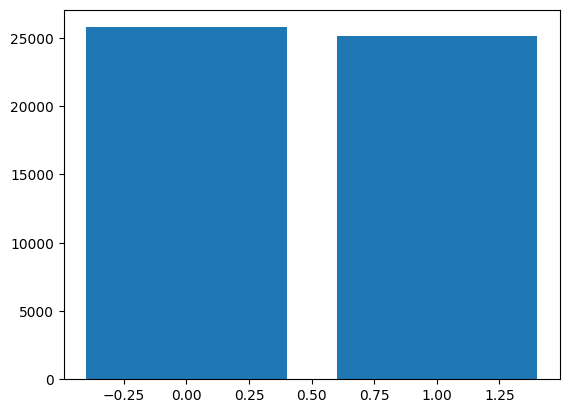

In [91]:
counts = train_df['label'].value_counts()
# print(counts)
# 0    500    ← class 0 appears 500 times
# 1    480    ← class 1 appears 480 times

# print(counts.index)   # [0, 1]    ← your x axis (class labels)
# print(counts.values)  # [500, 480] ← your y axis (how many of each)

plt.bar(counts.index,counts.values)
plt.show()

In [92]:
train_df.describe()

,label
count,50937.000000
mean,0.494081
std,0.499970
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [93]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50937 entries, 0 to 50936
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   images  50937 non-null  str  
 1   label   50937 non-null  int64
dtypes: int64(1), str(1)
memory usage: 796.0 KB


/var/folders/5p/1_5x2py97q7f5d89j76jx20c0000gn/T/ipykernel_1773/2349601424.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image = np.array(image).transpose(1,2,0) # these numbers are index position since i change the order for visualizition it is starting from " height, widt and channel"


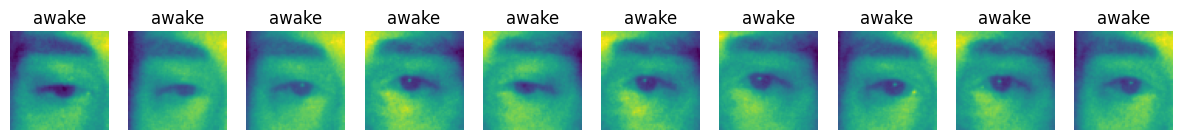

In [94]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    image, label = train_data[i]
    image = np.array(image).transpose(1,2,0) # these numbers are index position since i change the order for visualizition it is starting from " height, widt and channel"

    
    
    axes[i].imshow(image)
    axes[i].set_title(train_data.classes[label])
    axes[i].axis('off')

plt.show()

In [95]:
# creatign the model



class EyeCNN(nn.Module):
    def __init__(self):  # This is the constructor — it runs automatically when you create the model:


        super(EyeCNN, self).__init__() # This activates the parent's (nn.Module) constructor first before yours
        
        # Focuses on edges, shapes and classes
        self.model = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # 3x3(kernel_size)  → fine details (edges, small textures)
            # padding=1, it is telling to not srinhk and dont miss any ege of the image
            nn.ReLU(), # becomes negative number to " 0" and others stay as it is
            nn.MaxPool2d(2, 2),          # 64x64 → 32x32 it is comung from ' transforms.Resize((64, 64)), # resize all images 

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 32x32 → 16x16

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 16x16 → 8x8

           # resize any features to 4*4  
           nn.AdaptiveAvgPool2d((4, 4)), 

          # Classifier
           nn.Flatten(),                # Flatten just converts: (128, 8, 8) → 8192 numbers in a line
           nn.Linear(128 * 4 * 4, 512), # Linear layer needs: shape = (8192,)← 1D flat list, 512 is neuron numbers it is up to me , it starts from 128,512,1024
           nn.ReLU(),
           nn.Dropout(0.25),
           nn.Linear(512, 2) # 2 class such as open,close


        )



    def forward(self, x):
        return self.model(x)   # just passes to nn.Sequential!

    
# Create & print model
model = EyeCNN().to(device)
print(model)

EyeCNN(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=2048, out_features=512, bias=True)
    (12): ReLU()
    (13): Dropout(p=0.25, inplace=False)
    (14): Linear(in_features=512, out_features=2, bias=True)
  )
)


In [96]:
# creating criterion to see how bad the model prediction 
# criterion  → finds the error
# optimizer  → fixes the error

criterion = nn.CrossEntropyLoss() 

optimizer = torch.optim.Adam(model.parameters(), 
                            lr=learning_rate, # hyper paarmeter to 
                            weight_decay=1e-4
                            )




In [97]:
# Add this cell and run it:
images, labels = next(iter(train_loader))
print("Image dtype:", images.dtype)
print("Image shape:", images.shape)
print("Labels dtype:", labels.dtype)

Image dtype: torch.float32
Image shape: torch.Size([32, 1, 64, 64])
Labels dtype: torch.int64


In [102]:
# training the model
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    epochs: int = 15,
    print_every: int = 1,
    best_val_loss: float = float('inf'),
    patience: int = 3,
    trigger_times: int = 0,
    device: torch.device = None
) -> dict[str, list[float]]:

    history = {'train_loss': [], 'val_loss': [], 
               'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            if device is not None:
                images, labels = images.to(device), labels.to(device)

            # forward pass    
            optimizer.zero_grad()
            outputs = model(images) # [2.5, -1.3]   (raw scores), the model predict and give number for each class
            loss = criterion(outputs, labels) # 0.26 (how wrong = loss), it gets the prediction and turn this into percentage using CrossEntropLoss

            # backward pass
            loss.backward() # fix the model, calculating the gradienta and base on that the model is updated 
            optimizer.step() # and update the model base on loss.backward 

            # tracking metrics
            running_loss += loss.item() # adding " item()" giving only number "0.26" not " tensor(0.26)"
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:

                 # Move batch to device if specified
                if device is not None:
                    images, labels = images.to(device), labels.to(device)

                    
                outputs = model(images)
                loss = criterion(outputs, labels)


                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        # Record metrics
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '../models/best_model.pth')
            trigger_times = 0
            print(f"Epoch {epoch}: New best model saved!")
        else:
            trigger_times += 1
            print(f"Epoch {epoch}: No improvement. Strike {trigger_times}")

        if trigger_times >= patience:
            print("Stopping early to prevent overfitting.")
            break

        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(
                f'Epoch {epoch+1}/{epochs} - '
                f'loss: {train_loss:.4f} - '
                f'accuracy: {train_accuracy:.2f}% - '
                f'val_loss: {val_loss:.4f} - '
                f'val_accuracy: {val_accuracy:.2f}%'
            )

    print('\nTraining complete.')
    return history



In [103]:
%%time
# Call the model

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs = epoch,
    print_every = print_every,
    device = device
)

Epoch 0: New best model saved!
Epoch 1/25 - loss: 0.0768 - accuracy: 97.26% - val_loss: 0.0642 - val_accuracy: 97.74%
Epoch 1: New best model saved!
Epoch 2: New best model saved!
Epoch 3: New best model saved!
Epoch 4: No improvement. Strike 1
Epoch 5/25 - loss: 0.0519 - accuracy: 98.12% - val_loss: 0.0571 - val_accuracy: 97.84%
Epoch 5: No improvement. Strike 2
Epoch 6: New best model saved!
Epoch 7: No improvement. Strike 1
Epoch 8: No improvement. Strike 2
Epoch 9: No improvement. Strike 3
Stopping early to prevent overfitting.

Training complete.
CPU times: user 1min 57s, sys: 21.7 s, total: 2min 18s
Wall time: 3min 1s


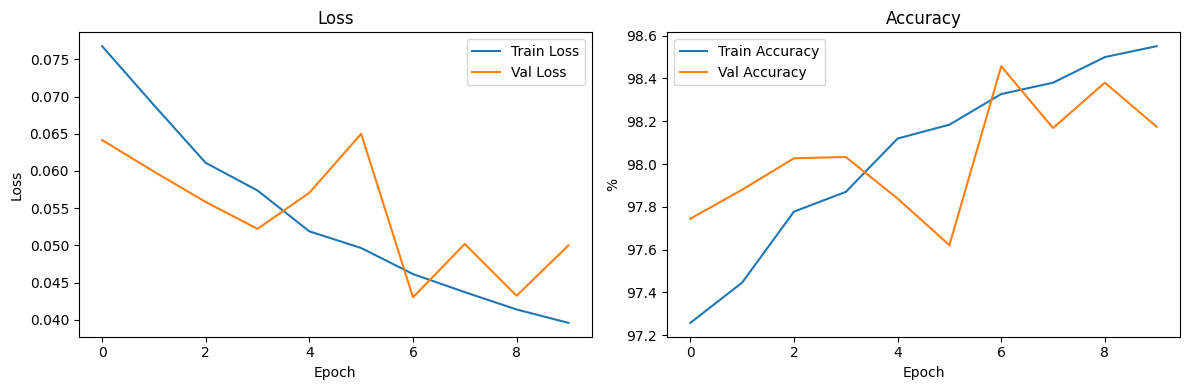

In [105]:


def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    # Accuracy plot
    axes[1].plot(history['train_accuracy'], label='Train Accuracy')
    axes[1].plot(history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('%')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

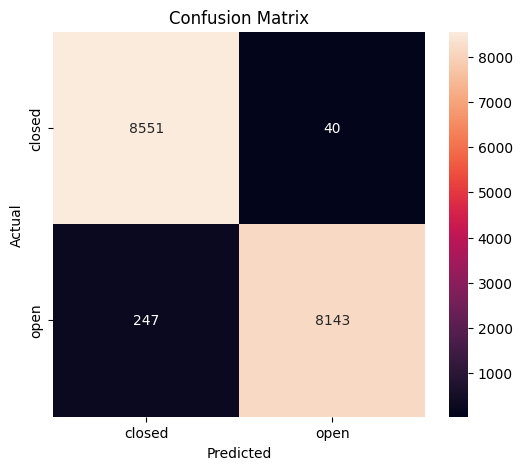

In [106]:


def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_predicted = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_predicted)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['closed', 'open'],
                yticklabels=['closed', 'open'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion_matrix(model, test_loader)